# Assigbment 1 — Monte Carlo Similuation: simulate the future for TOI newspaper sales return 🎲📈

**OPIM 5641 · Business Decision Modeling**

Name: Kapil Kumar Sharma

Husky CT: apl25002

Date: 09-20-2026

## Ask: How to do the Monte Carlo half (the recipe)

Your simulation must be connected to your dataset — not a copy of the class example with the numbers unchanged.

The recipe works for any dataset:

(1) pick one numeric column that represents something uncertain (daily sales, delivery times, prices, incomes…);

(2) turn it into a random draw — either fit a distribution using the column’s mean and standard deviation, or sample from the column’s actual values with replacement;

(3) wrap a for loop around a simple aggregate question and repeat it 10,000 times — “a year of sales return,”;

(4) histogram the outcomes and answer with a probability, not a single number: P(annual revenue < target), P(total time exceeds capacity) — with percentile lines on the plot.

In short: estimate the uncertain input from the data you have, then simulate the future you don’t have.

# The Normal Distribution

100 years of real returns
best year:  {'year': 1942.0, 'newspaper_sales_return': 0.091308, 'return_percent': 9.13}
worst year: {'year': 1931.0, 'newspaper_sales_return': -0.269357, 'return_percent': -26.94}


Text(0, 0.5, 'Frequency')

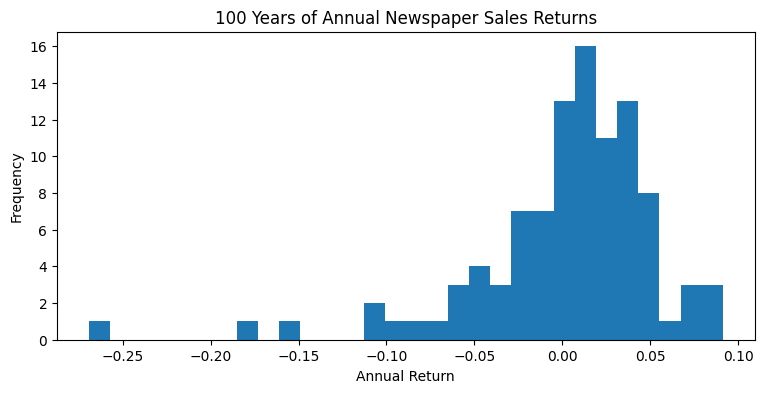

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/k-git-uconn/Studio1-BDM-F26/main/studio1/Assignment1/newspaper_sales_returns_1926_2025.csv'
toi = pd.read_csv(url)

revenue_history = toi['newspaper_sales_return'].values
print(len(revenue_history), 'years of real returns')

print('best year: ', toi.loc[toi.newspaper_sales_return.idxmax()].to_dict())
print('worst year:', toi.loc[toi.newspaper_sales_return.idxmin()].to_dict())

plt.figure(figsize=(9, 4))
plt.hist(revenue_history, bins=30)

plt.title('100 Years of Annual Newspaper Sales Returns')
plt.xlabel('Annual Return')
plt.ylabel('Frequency')

Comment: To load 100-year dataset and examining the historical return distribution.
This makes simulation data-driven/bootstrap-based.

In [61]:
simulations = 10_000
years = 25

initial_sales = 2_500_000

returns = toi['newspaper_sales_return'].values

all_paths = []

for simulation in range(simulations):

    sales = initial_sales
    path = []

    for year in range(years):

        r = np.random.choice(returns)

        sales = sales * (1 + r)

        path.append(sales)

    all_paths.append(path)

all_paths = np.array(all_paths)

Comment: Take the 100 annual newspaper-sales returns and uses bootstrap sampling with replacement to create 10,000 possible 25-year futures.

Text(0, 0.5, 'Annual Newspaper Sales')

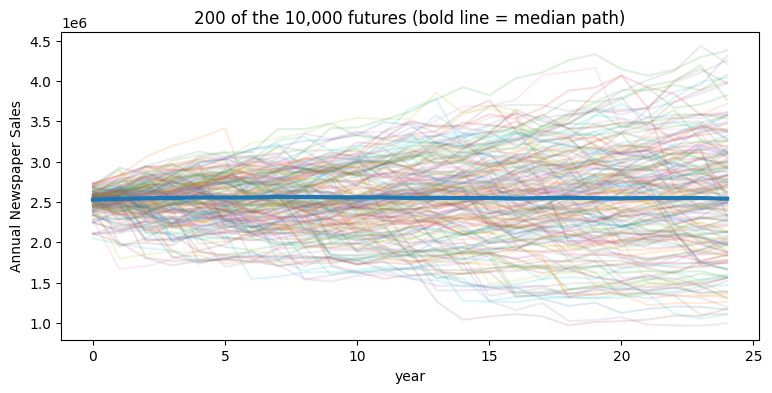

In [62]:
# The spaghetti plot — every future at once (plot a sample of 200)
plt.figure(figsize=(9, 4))
plt.plot(all_paths[:200].T, alpha=0.15)
plt.plot(np.median(all_paths, axis=0), lw=3)
plt.title('200 of the 10,000 futures (bold line = median path)')
plt.xlabel('year');
plt.ylabel('Annual Newspaper Sales')

Comment: This show 200 individual possible futures, while the bold line shows the median sales path across all 10,000 simulations.

In [63]:
endings = all_paths[:, -1]

target = 3_000_000

print(f'P(ending >= ${target:,.0f}) = {(endings >= target).mean():.1%}')

print(f'P(ending < $2,000,000) = {(endings < 2_000_000).mean():.1%}')

P(ending >= $3,000,000) = 26.7%
P(ending < $2,000,000) = 21.3%


Comment: What is the probability that annual newspaper sales after 25 years will be at least 3 million?

# The bootstrap simulation

In [64]:
n_sims = 10_000
years = 20

NewspapersSold = 6_000

endings = np.zeros(n_sims)
all_paths = np.zeros((n_sims, years))

for sim in range(n_sims):

    balance = 0.0

    for year in range(years):

        # Bootstrap: randomly select one of the 100 historical returns
        r = np.random.choice(revenue_history)

        balance = balance * (1 + r) + NewspapersSold

        all_paths[sim, year] = balance

    endings[sim] = balance

Comment: Every year, I add 6,000 newspapers to the accumulated balance.

In [65]:
n_sims = 10_000
years = 20

initial_sales = 2_500_000

endings = np.zeros(n_sims)
all_paths = np.zeros((n_sims, years))

for sim in range(n_sims):

    sales = initial_sales

    for year in range(years):

        # Bootstrap one annual newspaper-sales return
        r = np.random.choice(revenue_history)

        sales = sales * (1 + r)

        all_paths[sim, year] = sales

    endings[sim] = sales

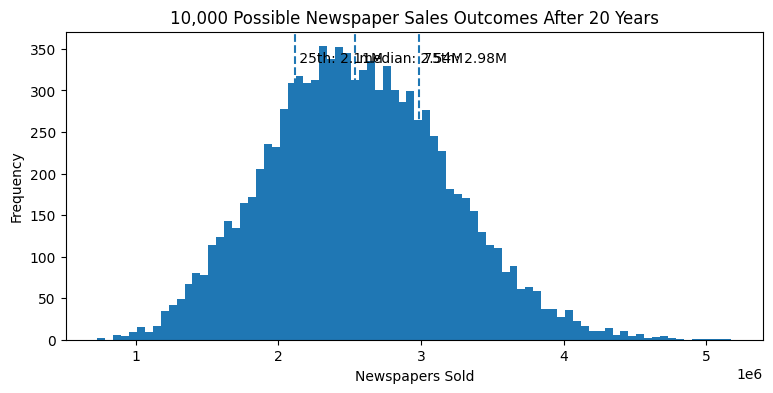

In [66]:
lo, med, hi = np.percentile(endings, [25, 50, 75])

plt.figure(figsize=(9, 4))

plt.hist(endings, bins=80)

for v, name in [(lo, '25th'), (med, 'median'), (hi, '75th')]:
    plt.axvline(v, ls='--')
    plt.text(
        v,
        plt.ylim()[1] * 0.9,
        f' {name}: {v/1e6:,.2f}M'
    )

plt.title('10,000 Possible Newspaper Sales Outcomes After 20 Years')
plt.xlabel('Newspapers Sold')
plt.ylabel('Frequency')

plt.show()

In [67]:
target = 2_000_000

print(
    f'P(ending >= 2 million) = '
    f'{(endings >= target).mean():.1%}'
)

print(
    f'P(ending < 1.5 million) = '
    f'{(endings < 1_500_000).mean():.1%}'
)

P(ending >= 2 million) = 80.9%
P(ending < 1.5 million) = 4.0%


# Compare the normal-distribution simulation with the bootstrap simulation.

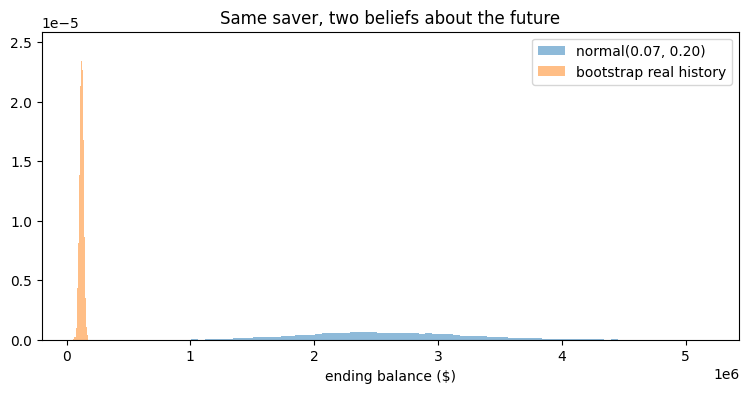

In [68]:
endings_boot = np.zeros(n_sims)
for sim in range(n_sims):
    balance = 0.0
    rs = toi['newspaper_sales_return'].sample(n=years, replace=True).values   # <-- THE line: resample real history
    for r in rs:
        balance = balance * (1 + r) + NewspapersSold
    endings_boot[sim] = balance

plt.figure(figsize=(9, 4))
plt.hist(endings, bins=80, alpha=0.5, label='normal(0.07, 0.20)', density=True)
plt.hist(endings_boot, bins=80, alpha=0.5, label='bootstrap real history', density=True)
plt.legend()
plt.title('Same saver, two beliefs about the future')
plt.xlabel('ending balance ($)');

In [70]:
for name, e in [('normal', endings), ('bootstrap', endings_boot)]:
    print(f'{name:>9}:  median ${np.median(e)/1e6:.2f}M   P(>=$1M) {(e>=1e6).mean():.1%}   P(<$500k) {(e<5e5).mean():.1%}')


   normal:  median $2.54M   P(>=$1M) 99.8%   P(<$500k) 0.0%
bootstrap:  median $0.12M   P(>=$1M) 0.0%   P(<$500k) 100.0%
